In [1]:
# Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#(Q1) Load and Display Data
df = pd.read_csv("gym.csv")
print("Dataframe:")
df.head(10)

Dataframe:


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
5,56,Female,58.0,1.68,168,156,74,1.59,1116.0,HIIT,15.5,2.7,5,3,20.55
6,36,Male,70.3,1.72,174,169,73,1.49,1385.0,Cardio,21.3,2.3,3,2,23.76
7,40,Female,69.7,1.51,189,141,64,1.27,895.0,Cardio,30.6,1.9,3,2,30.57
8,28,Male,121.7,1.94,185,127,52,1.03,719.0,Strength,28.9,2.6,4,2,32.34
9,28,Male,101.8,1.84,169,136,64,1.08,808.0,Cardio,29.7,2.7,3,1,30.07


In [2]:
# Rows and Columns
print("No. of rows/records: ",df.shape[0])
print("No. of columns/attributes: ",df.shape[1])

No. of rows/records:  973
No. of columns/attributes:  15


In [3]:
# Check for missing values
print("Missing values before handling:\n")
print(df.isnull().sum())

Missing values before handling:

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64


In [4]:
# String Manipulation, Data Transformation and Cleaning:

## Replace spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

## Convert gender to lowercase for consistency
df['gender'] = df['gender'].str.lower()

# Data Aggegration and Grouping:
#(Q2)
## Create BMI category (feature engineering)
def bmi_category(bmi):
    if bmi < 18.5:
        return "underweight"
    elif bmi < 25:
        return "normal"
    elif bmi < 30:
        return "overweight"
    else:
        return "obese"

df['bmi_category'] = df['bmi'].apply(bmi_category)


In [5]:
#(Q3)
## Create age groups (binning)
df['age_group'] = pd.cut(df['age'],
                         bins=[18, 25, 35, 45, 60],
                         labels=['18-25', '26-35', '36-45', '46-60'])
#(Q4)
## Average calories burned by workout type
calories_by_workout = df.groupby('workout_type')['calories_burned'].mean().sort_values()

## Average BMI by gender
bmi_by_gender = df.groupby('gender')['bmi'].mean()

## Workout frequency by experience level
workout_exp = df.groupby('experience_level')['workout_frequency_(days/week)'].mean()

In [6]:
# INSIGHTS

print("\n--- Key Observations ---")

print("\n1. Average Calories Burned by Workout Type:")
print(calories_by_workout)

print("\n2. Average BMI by Gender:")
print(bmi_by_gender)

print("\n3. Workout Frequency by Experience Level:")
print(workout_exp)



--- Key Observations ---

1. Average Calories Burned by Workout Type:
workout_type
Cardio      884.513725
Yoga        903.188285
Strength    910.697674
HIIT        925.805430
Name: calories_burned, dtype: float64

2. Average BMI by Gender:
gender
female    22.727835
male      26.886967
Name: bmi, dtype: float64

3. Workout Frequency by Experience Level:
experience_level
1    2.476064
2    3.534483
3    4.534031
Name: workout_frequency_(days/week), dtype: float64


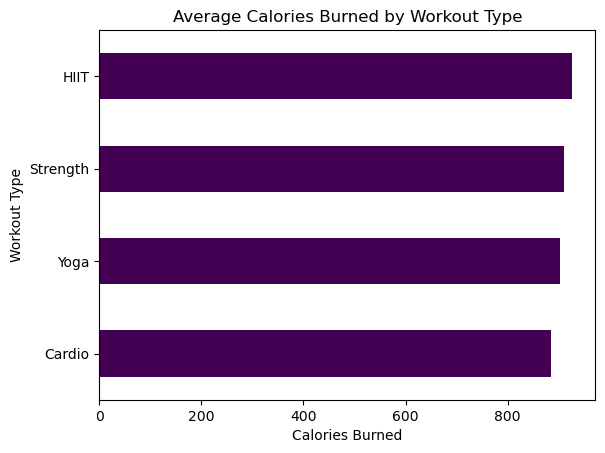

The most effective workout type in terms of calorie burn is HIIT with an average of 925.81 calories burned, while the least effective is Cardio with 884.51 calories burned.


In [7]:
# (i) VISUALIZATIONS with Insights
#(Q5)
# --- F1. Calories Burned by Workout Type (horizontal bar chart) ---
plt.figure()
calories_by_workout.plot(kind='barh', colormap='viridis')
plt.title("Average Calories Burned by Workout Type")
plt.xlabel("Calories Burned")
plt.ylabel("Workout Type")
plt.show()

max_workout = calories_by_workout.idxmax()
min_workout = calories_by_workout.idxmin()

max_value = calories_by_workout.max()
min_value = calories_by_workout.min()

# Print insight
print(f"The most effective workout type in terms of calorie burn is {max_workout} "
      f"with an average of {max_value:.2f} calories burned, "
      f"while the least effective is {min_workout} with {min_value:.2f} calories burned.")

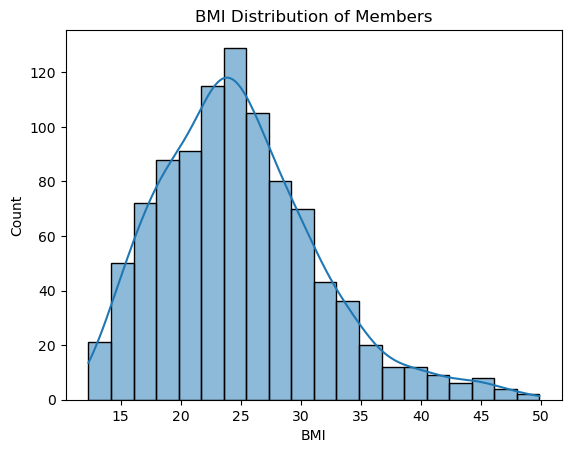

The BMI distribution of gym members is centered around a mean of 24.91 and a median of 24.16. 


In [8]:
#(Q6)
# --- F2. BMI Distribution (histogram) ---
plt.figure()
sns.histplot(df['bmi'], bins=20, kde=True)
plt.title("BMI Distribution of Members")
plt.xlabel("BMI")
plt.show()

mean_bmi = df['bmi'].mean()
median_bmi = df['bmi'].median()
# Insight
print(f"The BMI distribution of gym members is centered around a mean of {mean_bmi:.2f} and a median of {median_bmi:.2f}. ")

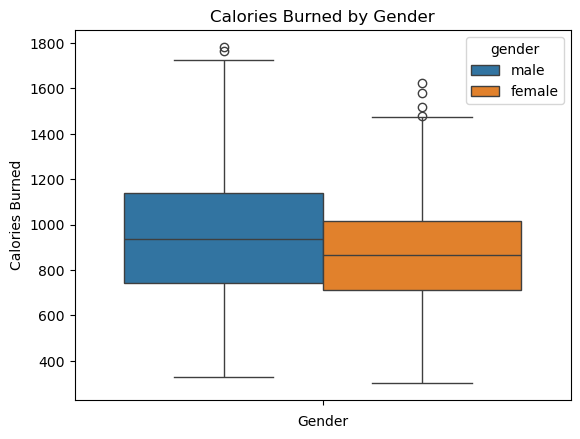

Males tend to burn slightly more calories on average, with a wider distribution indicating greater variability in workout intensity.


In [9]:
#(Q7)
# --- F3. Gender vs Calories Burned (box plot)---
plt.figure()
sns.boxplot(hue='gender', y='calories_burned', data=df,legend = True)
plt.title("Calories Burned by Gender")
plt.xlabel("Gender")
plt.ylabel("Calories Burned")
plt.show()

# Insight
print("Males tend to burn slightly more calories on average, with a wider distribution indicating greater variability in workout intensity.")


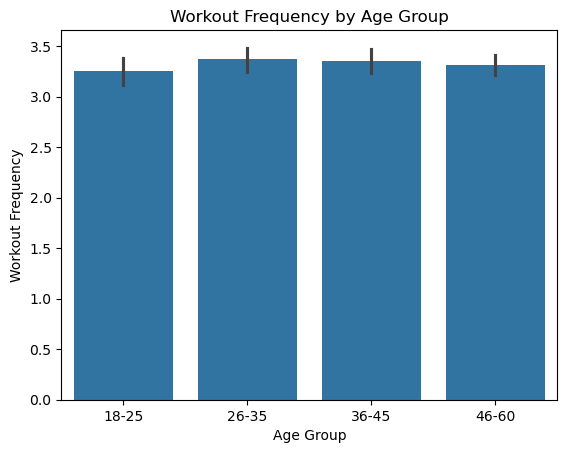

Workout frequency is fairly consistent across all age groups, with only slight variations between 3 and 3.5 days per week.


In [10]:
#(Q8)
# --- F4. Workout Frequency vs Age Group (bar plot) ---
plt.figure()
sns.barplot(x='age_group', y='workout_frequency_(days/week)', data=df)
plt.title("Workout Frequency by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Workout Frequency")
plt.show()

# Insight
print("Workout frequency is fairly consistent across all age groups, with only slight variations between 3 and 3.5 days per week.")

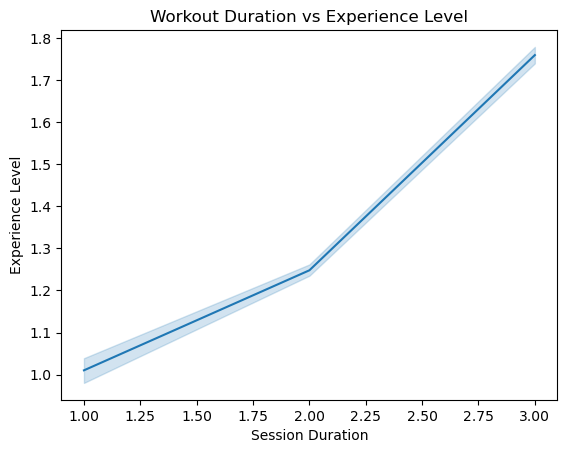

Workout duration generally increases with experience level, though the trend is not perfectly consistent across all levels.


In [11]:
#(Q9)
# --- F5. Experience Level vs Workout Duration (line plot) ---
plt.figure()
sns.lineplot(x='experience_level', y='session_duration_(hours)', data=df)
plt.title("Workout Duration vs Experience Level")
plt.xlabel("Session Duration")
plt.ylabel("Experience Level")
plt.show()

# Insight 
print("Workout duration generally increases with experience level, though the trend is not perfectly consistent across all levels.")

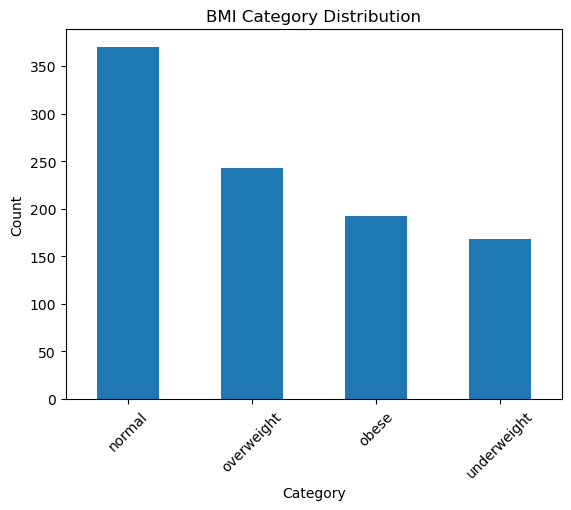

Most individuals fall under the normal BMI category, followed by overweight and obese groups, while the underweight category has the lowest count.


In [12]:
#(Q10)
# --- F6. BMI Category vs Count (vertical bar chart) ---
plt.figure()
df['bmi_category'].value_counts().plot(kind='bar')
plt.title("BMI Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation = 45)
plt.show()

#Insight
print("Most individuals fall under the normal BMI category, followed by overweight and obese groups, while the underweight category has the lowest count.")

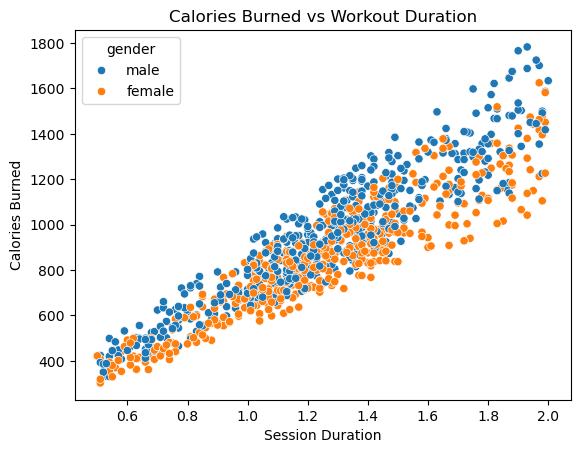

['male' 'female']
There is a positive relationship between workout duration and calories burned, with males reaching up to 1783.00 calories and females going as low as 303.00 calories.


In [13]:
#(Q11)
# --- F7. Calories Burned vs Workout Duration (scatter plot) ---
plt.figure()
sns.scatterplot(x='session_duration_(hours)', y='calories_burned', hue='gender', data=df)
plt.title("Calories Burned vs Workout Duration")
plt.xlabel("Session Duration")
plt.ylabel("Calories Burned")
plt.show()

#INSIGHTS
print(df['gender'].unique())
max_male = df[df['gender'] == 'male']['calories_burned'].max()
min_female = df[df['gender'] == 'female']['calories_burned'].min()

print(f"There is a positive relationship between workout duration and calories burned, with males reaching up to {max_male:.2f} calories and females going as low as {min_female:.2f} calories.")

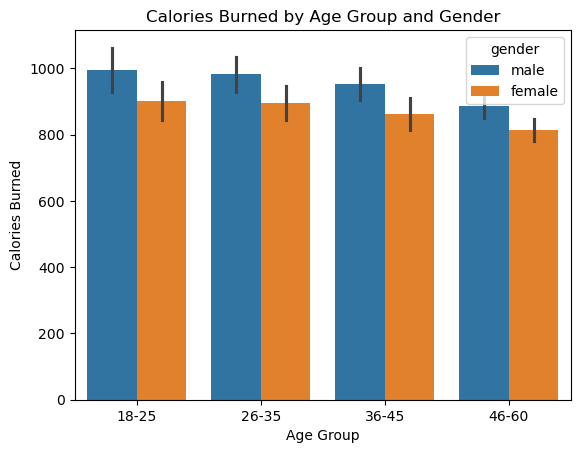

Calorie burn varies slightly across age groups, with consistent gender differences observed within each group.


In [14]:
#(Q12)
# --- F8. Calories by age group and gender (bar plot) ---
plt.figure()
sns.barplot(x='age_group', y='calories_burned', hue='gender', data=df)
plt.title("Calories Burned by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Calories Burned")
plt.show()

#INSIGHTS
print("Calorie burn varies slightly across age groups, with consistent gender differences observed within each group.")


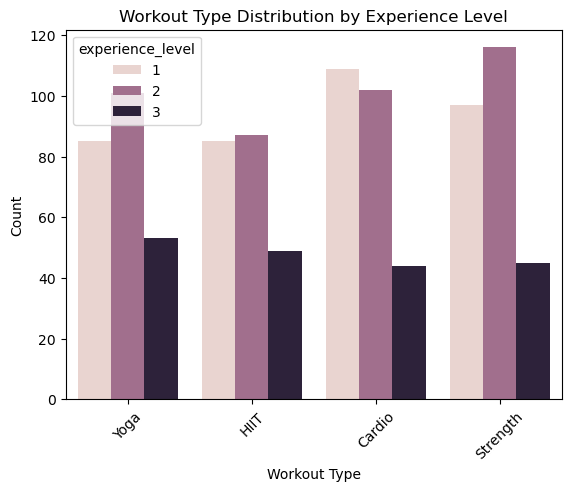

Workout types are fairly evenly distributed across experience levels, with some variations indicating preferences for certain workouts at different levels.


In [15]:
#(Q13)
# --- F9. Workout Type vs Experience level (count plot) ---
plt.figure()
sns.countplot(x='workout_type', hue='experience_level', data=df)
plt.xticks(rotation=45)
plt.xlabel("Workout Type")
plt.ylabel("Count")
plt.title("Workout Type Distribution by Experience Level")
plt.show()

#Insights
print("Workout types are fairly evenly distributed across experience levels, with some variations indicating preferences for certain workouts at different levels.")

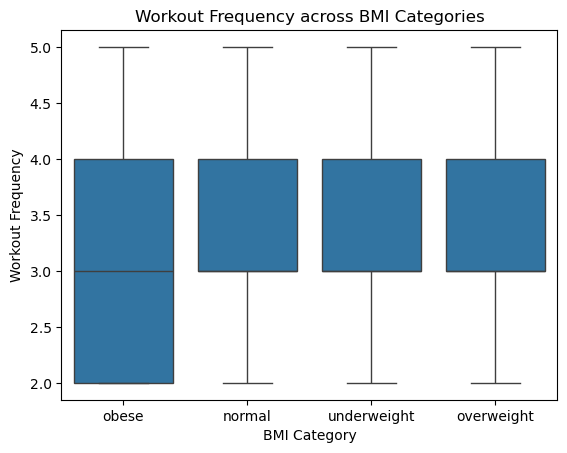

Workout frequency is slightly lower and more variable in the obese category (2–4 days/week), while other BMI groups show a more consistent range of 3–4 days/week.


In [16]:
#(Q14)
# --- F10. Workout Frequency vs BMI (box plot) ---
plt.figure()
sns.boxplot(x='bmi_category', y='workout_frequency_(days/week)', data=df)
plt.title("Workout Frequency across BMI Categories")
plt.xlabel("BMI Category")
plt.ylabel("Workout Frequency")
plt.show()

#Insights
print("Workout frequency is slightly lower and more variable in the obese category (2–4 days/week), while other BMI groups show a more consistent range of 3–4 days/week.")

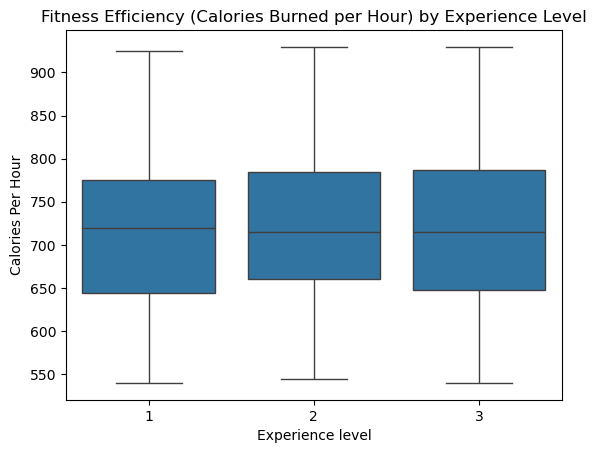

Fitness efficiency tends to improve with higher experience levels, showing higher median calories burned per hour and slightly reduced variability.


In [17]:
#(Q15)
# FITNESS EFFICIENCY METRIC
df['calories_per_hour'] = df['calories_burned'] / df['session_duration_(hours)']

# ---F11. Fitness efficiency by experience level (box plot)---
plt.figure()
sns.boxplot(x='experience_level', y='calories_per_hour', data=df)
plt.title("Fitness Efficiency (Calories Burned per Hour) by Experience Level")
plt.xlabel("Experience level")
plt.ylabel("Calories Per Hour")
plt.show()

#Insights
print("Fitness efficiency tends to improve with higher experience levels, showing higher median calories burned per hour and slightly reduced variability.")